# Fresh PCB2 confirmation of the frozen normal-reference procedure

This companion reads saved tables, figures, configuration and review receipts.
It needs neither raw images nor cached features, memory banks or weights, and
performs no acquisition, feature extraction, selection, calibration or inference.

D1 at 256 is the declared primary. D2 at 512 remains a secondary result regardless
of its outcome. PCB1 results are development history; this is category-adapted
confirmation with newly fitted PCB2 normal references, not zero-shot transfer.
The synopsis below is computed from the reviewed saved results.

In [1]:
from pathlib import Path
import hashlib, json
import pandas as pd
from IPython.display import display, Image, Markdown
root = Path.cwd()
if not (root / 'artifacts').is_dir():
    root = root.parent
stage = root / 'artifacts/stage4'
folder = stage / 'comparison'
def load_json(path):
    return json.loads(path.read_text())
def sha(path):
    return hashlib.sha256(path.read_bytes()).hexdigest()
def show_table(name):
    display(pd.read_csv(folder / name).round(4))
def show_figure(name):
    display(Image(filename=str(folder / 'figures' / name)))
metadata = load_json(folder / 'report_metadata.json')
assert metadata['new_model_inference'] is False
for name, expected in metadata['outputs'].items():
    path = (folder / name).resolve()
    assert path.is_relative_to(folder.resolve()), 'Unsafe report output path'
    assert sha(path) == expected, f'Report output changed: {name}'
config = load_json(root / 'configs/stage4_protocol.json')
freeze = stage / 'freeze_receipt.json'
freeze_data = load_json(freeze)
assert freeze_data['config'] == config
reviews = []
for run in ['pcb2_d1_primary', 'pcb2_d2_secondary']:
    run_folder = stage / run
    normal = load_json(run_folder / 'independent_normal_review.json')
    review = load_json(run_folder / 'independent_review.json')
    assert normal['passed'] and review['passed']
    assert normal['prepared_sha256'] == sha(run_folder / 'prepared.json')
    assert review['complete_sha256'] == sha(run_folder / 'complete.json')
    assert review['freeze_receipt_sha256'] == sha(freeze)
    assert review['normal_review_sha256'] == sha(run_folder / 'independent_normal_review.json')
    reviews.append({'run': run, 'normal_review_passed': normal['passed'],
                    'confirmation_review_passed': review['passed']})
results = pd.read_csv(folder / 'd1_vs_d2.csv')
assert set(results.recipe) == {'D1 primary', 'D2 secondary'}
primary = results.set_index('recipe').loc['D1 primary']
print('Saved reports and both independent review chains verified. No raw/cache reads.')

Saved reports and both independent review chains verified. No raw/cache reads.


## Primary result and declared project criteria

All four practical criteria are jointly required. They were declared before
unsealing and are project feasibility checks, not statistical equivalence tests
or factory acceptance targets. Lower normal false-alarm rate is better.

,criterion,observed,comparison,declared_limit,passed
0,Anomaly recall,0.8000,>=,0.80,True
1,Normal false-alarm rate,0.0500,<=,0.10,True
2,Median common 256 anomaly pixel AP,0.3245,>=,0.25,True
3,Peak-inside fraction,0.4400,>=,0.40,True


D1 recall **80.0%**, normal FPR **5.0%**, median anomaly pixel AP **0.325**. All four project criteria: **passed**.

,recipe,category,size,tp,fp,fn,tn,recall,normal_false_alarm_rate,average_precision,auroc,median_pixel_ap,q25,q75,pooled_pixel_ap,pixel_iou,peak_inside_count,overlap_count,median_inference_seconds,p95_inference_seconds
0,D1 primary,PCB2,256,80,5,20,95,0.80,0.05,0.9604,0.9499,0.3245,0.1171,0.5136,0.1534,0.0474,44,97,0.2918,0.3064
1,D2 secondary,PCB2,512,91,4,9,96,0.91,0.04,0.9770,0.9697,0.4957,0.2967,0.6723,0.2766,0.0704,71,100,1.0757,1.1169


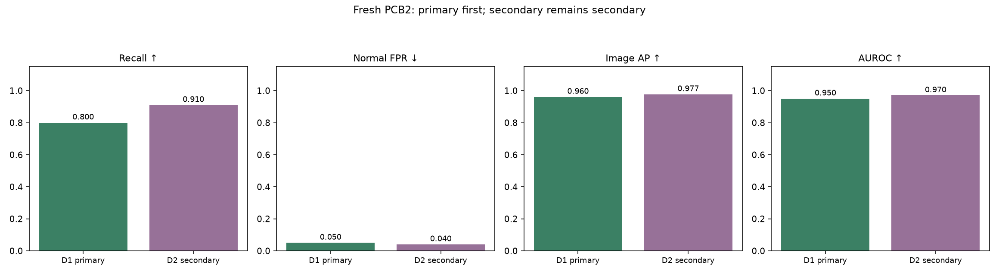

In [2]:
criteria = config['primary_practical_criteria']
anomaly_count = int(primary.tp + primary.fn)
criterion_rows = [
    ('Anomaly recall', primary.recall, '>=', criteria['recall_minimum']),
    ('Normal false-alarm rate', primary.normal_false_alarm_rate, '<=', criteria['normal_fpr_maximum']),
    ('Median common 256 anomaly pixel AP', primary.median_pixel_ap, '>=', criteria['median_common_pixel_ap_minimum']),
    ('Peak-inside fraction', primary.peak_inside_count / anomaly_count, '>=', criteria['peak_inside_fraction_minimum']),
]
criteria_table = pd.DataFrame(criterion_rows, columns=['criterion', 'observed', 'comparison', 'declared_limit'])
criteria_table['passed'] = [value >= limit if sign == '>=' else value <= limit
                           for _, value, sign, limit in criterion_rows]
display(criteria_table.round(4))
display(Markdown(f"D1 recall **{primary.recall:.1%}**, normal FPR **{primary.normal_false_alarm_rate:.1%}**, "
    f"median anomaly pixel AP **{primary.median_pixel_ap:.3f}**. "
    f"All four project criteria: **{'passed' if criteria_table.passed.all() else 'not passed'}**."))
show_table('d1_vs_d2.csv')
show_figure('detection.png')

## Frozen methods and normal-only geometry review

Both recipes retain frozen ResNet18 features, projected approximate greedy
selection from all fitting patches, 4,096 full 384-dimensional reference vectors,
Euclidean nearest-reference distance and maximum-patch image scoring. The
64-dimensional projection is used only for selection. Each recipe calibrates
its own thresholds from normal images with `higher` quantiles and strict `>`.

The inherited blue-margin crop and letterbox geometry was approved on construction
normals before final freeze. Held-out normals did not participate in adaptation.
These contact sheets are saved preflight evidence, not a new image read.

primary                                                            pcb2_d1_primary,256
secondary                            pcb2_d2_secondary,512; never post-result fallback
normal_split_counts                  {'fit': 720, 'calibration': 181, 'normal_test'...
selector                             {'memory_count': 4096, 'all_fitting_candidates...
calibration                          {'image_quantile': 0.95, 'pixel_quantile': 0.9...
geometry                             {'mode': 'inherited_blue', 'id': 'pcb1-blue-ma...
caps                                 {'peak_rss_bytes': 8589934592, 'preparation_se...
anomaly_access_before_finalfreeze                                                False
retuning_after_unseal                                                            False
dtype: object

,run,normal_review_passed,confirmation_review_passed
0,pcb2_d1_primary,True,True
1,pcb2_d2_secondary,True,True


,image_id,reason
0,a88a25248879338f42b7b8d5,crop_area_fraction minimum
1,7ff10d5fa9617322c74f0a6b,crop_area_fraction maximum
2,3b739922cafc7c1c1b6bf5af,crop_aspect_ratio maximum
3,f7ab54038434a0fb639afdd3,component_fraction minimum
4,a62dae09b2226f081de0d80f,component_fraction maximum
5,003a70a56fc2e5bf41362c4b,systematic sorted normal sample
6,1341a4d254c5ed4e53f9cc0a,systematic sorted normal sample
7,29dc8d4c0e70ced218f864d9,systematic sorted normal sample
8,4076636edff1ff18d23dd18f,systematic sorted normal sample
9,577e306a2e950842cc7e0b3b,systematic sorted normal sample


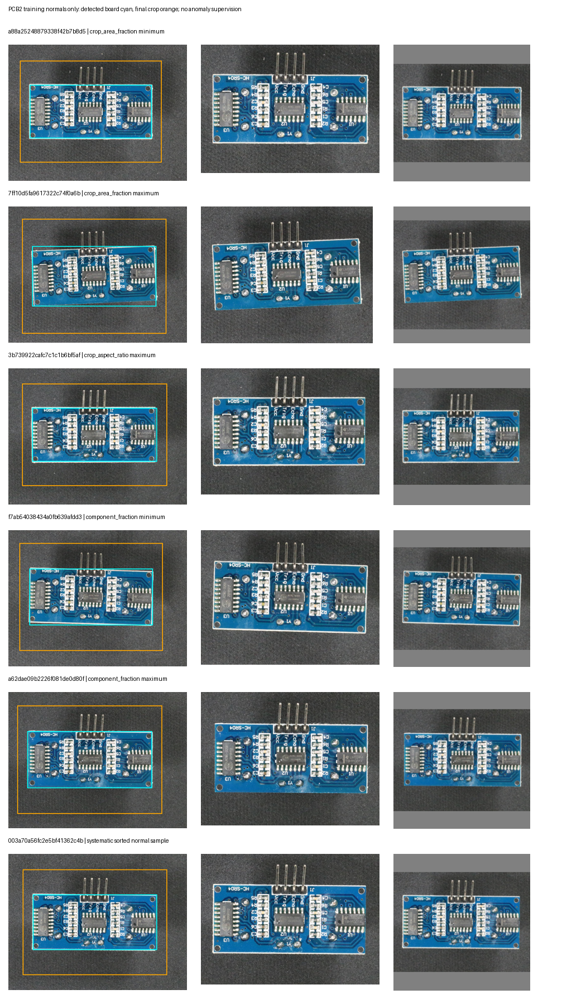

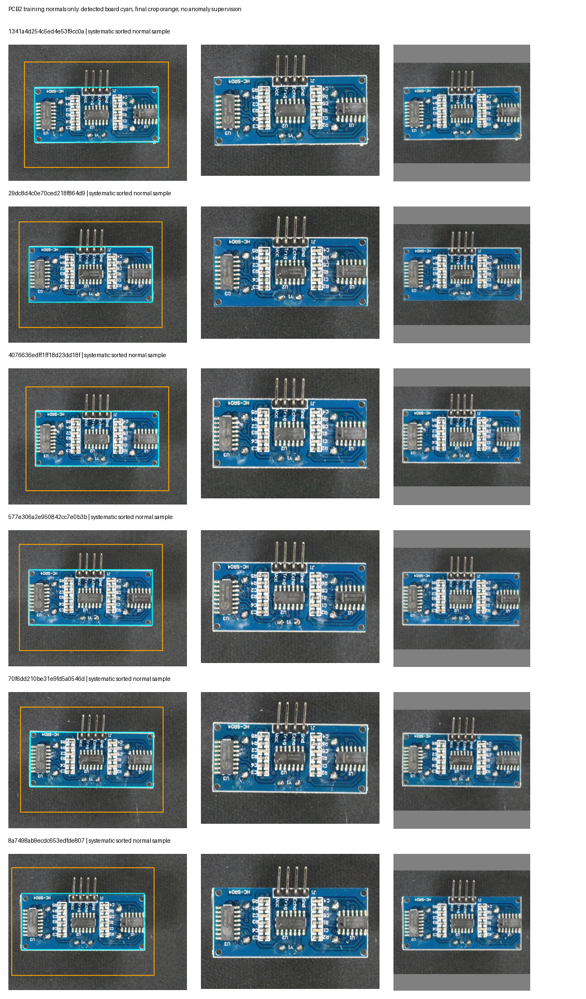

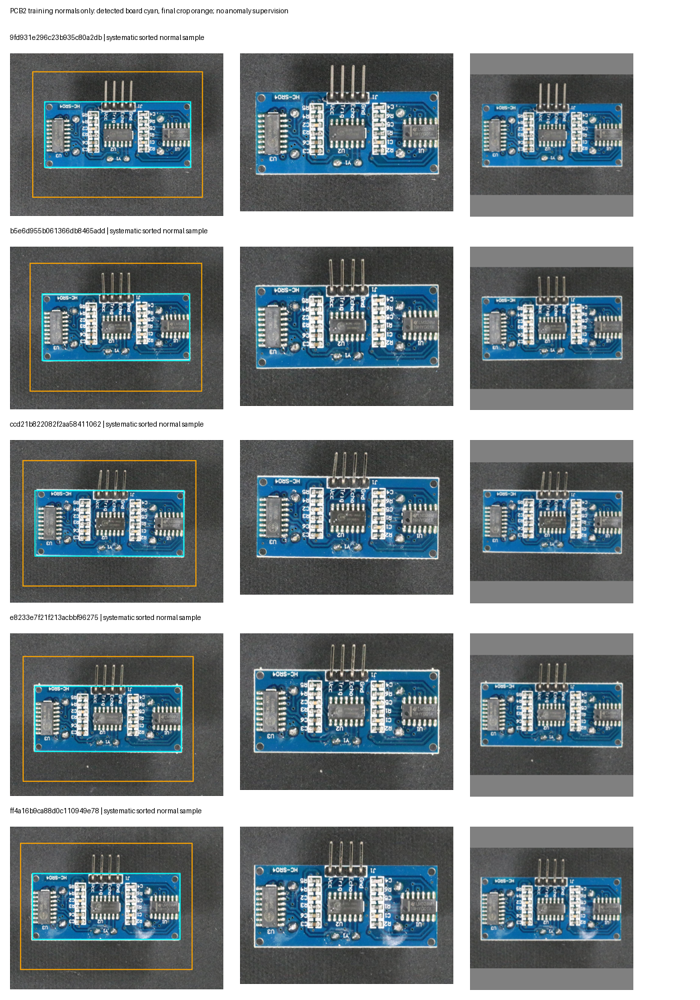

In [3]:
display(pd.Series({key: config[key] for key in [
    'primary', 'secondary', 'normal_split_counts', 'selector', 'calibration',
    'geometry', 'caps', 'anomaly_access_before_finalfreeze', 'retuning_after_unseal']}))
display(pd.DataFrame(reviews))
geometry_folder = stage / 'geometry_preflight'
geometry_review = load_json(geometry_folder / 'normal_geometry_review.json')
assert geometry_review['passed'] and geometry_review['geometry'] == config['geometry']
display(pd.read_csv(geometry_folder / 'visual_selection.csv'))
for sheet in sorted(geometry_folder.glob('normal_contact_sheet_*.png')):
    display(Image(filename=str(sheet)))

## Localization and defect slices

Common 256 maps cover the whole source frame; outside-crop scores are zero.
Ground truth retains every annotated region. Pixel AP measures ranking, and
heatmap values are not probabilities. Type memberships may overlap and must not
be added as independent images. Fixed PCB1 area boundaries are reference bands
on PCB2; PCB2's own area quartiles are a supplemental descriptive view. Small or
empty groups remain visible and do not establish subgroup reliability.

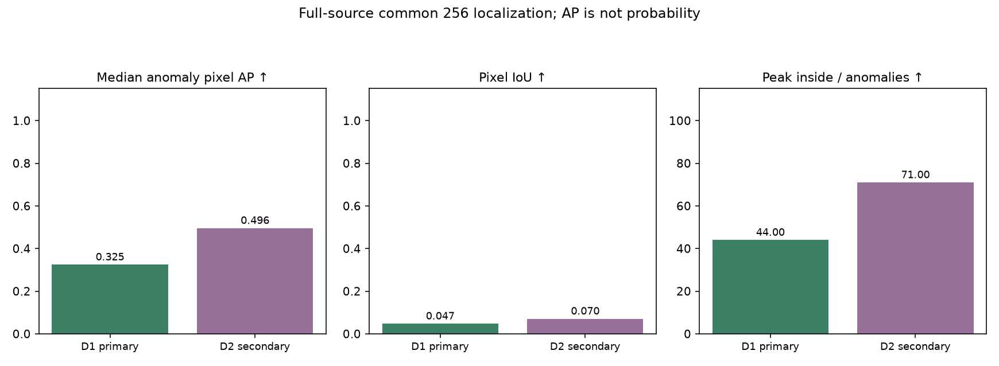

,recipe,group,count,detected,recall,median_pixel_ap
0,D1 primary,bent,15,14,0.9333,0.2350
1,D1 primary,melt,55,42,0.7636,0.3564
2,D1 primary,missing,19,12,0.6316,0.0757
3,D1 primary,scratch,20,18,0.9000,0.3226
4,D2 secondary,bent,15,15,1.0000,0.3665
5,D2 secondary,melt,55,52,0.9455,0.6569
6,D2 secondary,missing,19,13,0.6842,0.2087
7,D2 secondary,scratch,20,20,1.0000,0.5070


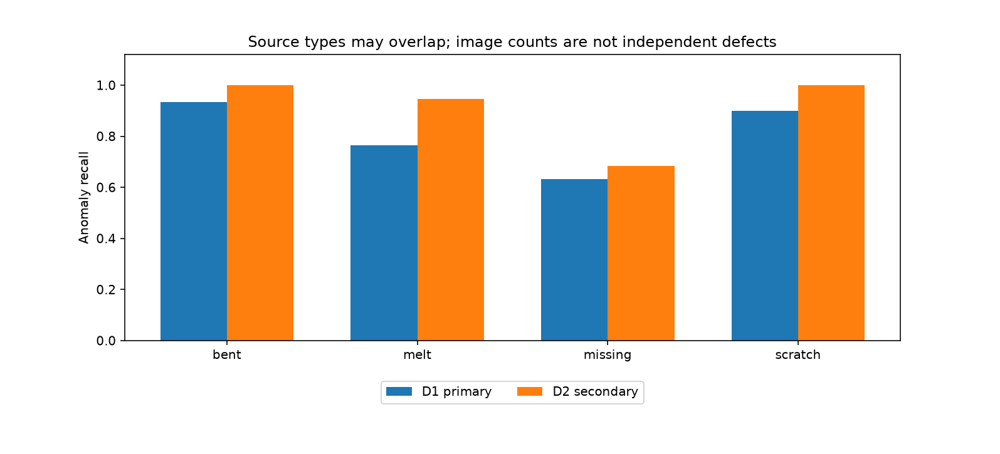

,recipe,group,count,detected,recall,median_pixel_ap
0,D1 primary,PCB1 area band 1,14,7,0.5000,0.1092
1,D1 primary,PCB1 area band 2,15,8,0.5333,0.2232
2,D1 primary,PCB1 area band 3,34,29,0.8529,0.3290
3,D1 primary,PCB1 area band 4,37,36,0.9730,0.4318
4,D2 secondary,PCB1 area band 1,14,9,0.6429,0.3423
5,D2 secondary,PCB1 area band 2,15,12,0.8000,0.5853
6,D2 secondary,PCB1 area band 3,34,33,0.9706,0.5187
7,D2 secondary,PCB1 area band 4,37,37,1.0000,0.4932


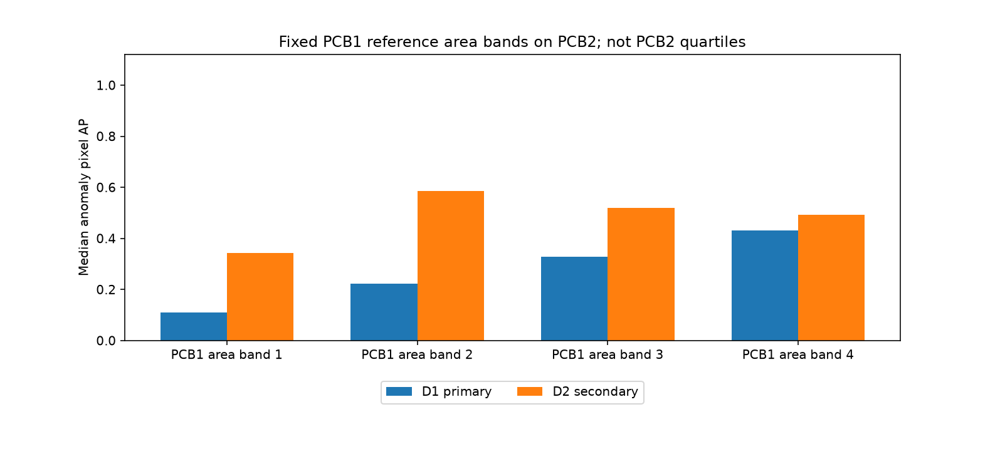

,recipe,group,count,detected,recall,median_pixel_ap,q25_edge,q50_edge,q75_edge
0,D1 primary,PCB2 Q1,27,14,0.5185,0.2035,0.0018,0.0027,0.0039
1,D1 primary,PCB2 Q2,24,18,0.7500,0.2646,0.0018,0.0027,0.0039
2,D1 primary,PCB2 Q3,25,25,1.0000,0.4131,0.0018,0.0027,0.0039
3,D1 primary,PCB2 Q4,24,23,0.9583,0.4258,0.0018,0.0027,0.0039
4,D2 secondary,PCB2 Q1,27,19,0.7037,0.4319,0.0018,0.0027,0.0039
5,D2 secondary,PCB2 Q2,24,23,0.9583,0.6120,0.0018,0.0027,0.0039
6,D2 secondary,PCB2 Q3,25,25,1.0000,0.4837,0.0018,0.0027,0.0039
7,D2 secondary,PCB2 Q4,24,24,1.0000,0.4813,0.0018,0.0027,0.0039


In [4]:
show_figure('localization.png')
show_table('defect_type.csv')
show_figure('defect_type_recall.png')
show_table('defect_size.csv')
show_figure('defect_size.png')
show_table('pcb2_size_quartiles.csv')

## Score scales, latency and development history

Thresholds are frozen normal-only estimates; no anomaly-driven threshold search
is performed. Scores have recipe-specific scales. Normal FPR describes review
burden on this sample. Saved CPU latency describes the measured environment.
Category differences mean PCB1-to-PCB2 changes do not isolate a causal mechanism.

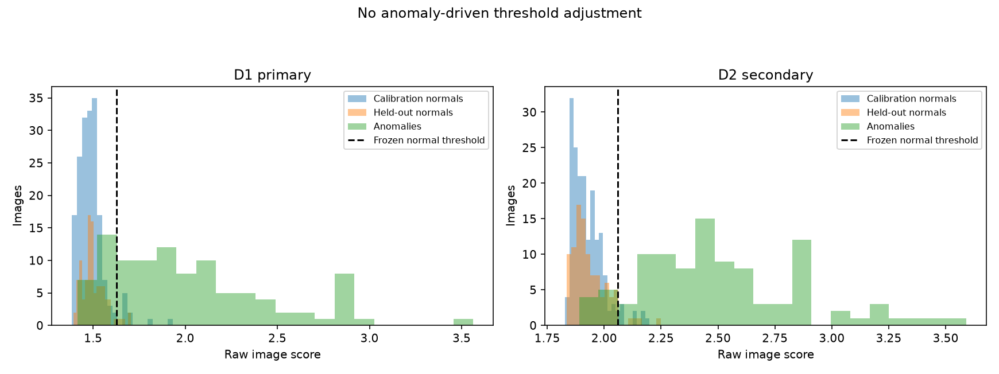

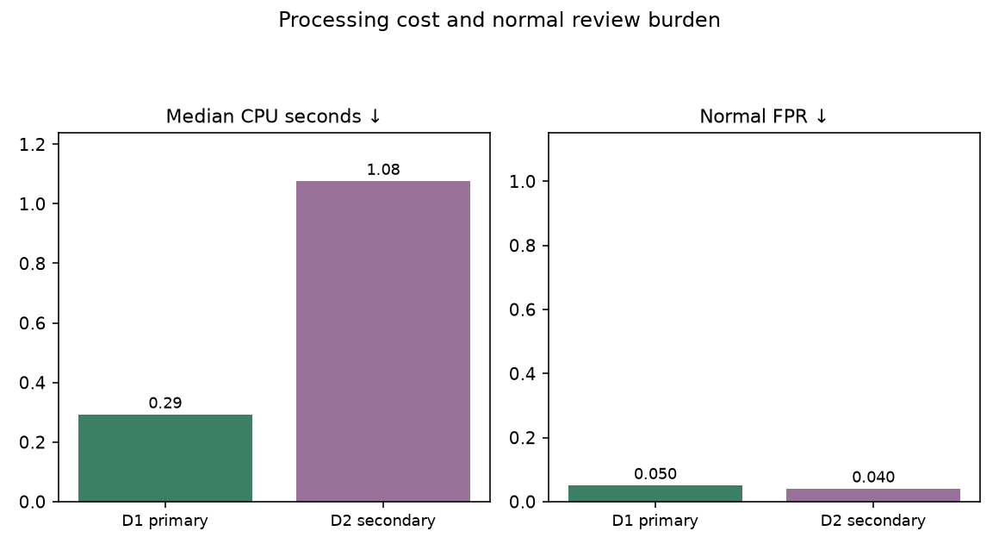

,recipe,measured_perf_counter_preparation_seconds,utc_preparation_span_seconds,calendar_span_not_bounded_by_frozen_perf_counter_gate,normal_preparation_peak_rss_bytes,normal_median_inference_seconds,evaluation_peak_rss_bytes,count,candidate_count,fraction,represented_fit_images,padding_center_fraction
0,D1 primary,207.1347,2457.0937,True,1153318912,0.6186,1537736704,4096,737280,0.0056,676,0.0107
1,D2 secondary,652.3351,2942.6527,True,2935586816,2.2752,1342603264,4096,2949120,0.0014,696,0.0046


,recipe,phase,seconds,peak_rss_bytes
0,D1 primary,backbone_load,0.6837,526761984
1,D1 primary,projection,38.9376,858292224
2,D1 primary,selection,30.0833,1153318912
3,D1 primary,reextraction,40.6398,1153318912
4,D1 primary,calibration,96.5909,1153318912
5,D2 secondary,backbone_load,0.6657,526385152
6,D2 secondary,projection,84.8681,1663729664
7,D2 secondary,selection,140.2857,2935586816
8,D2 secondary,reextraction,81.8178,2935586816
9,D2 secondary,calibration,344.1208,2935586816


,recipe,category,size,tp,fp,fn,tn,recall,normal_false_alarm_rate,average_precision,auroc,median_pixel_ap,q25,q75,pooled_pixel_ap,pixel_iou,peak_inside_count,overlap_count,median_inference_seconds,p95_inference_seconds
0,D1 primary,PCB1 development,256,89,4,11,96,0.89,0.04,0.9680,0.9731,0.3529,0.1881,0.5641,0.8452,0.1153,49,99,0.2909,0.2964
1,D2 secondary,PCB1 development,512,95,11,5,89,0.95,0.11,0.9760,0.9782,0.5348,0.3583,0.7683,0.8300,0.1411,71,98,1.0807,1.1376
2,D1 primary,PCB2,256,80,5,20,95,0.80,0.05,0.9604,0.9499,0.3245,0.1171,0.5136,0.1534,0.0474,44,97,0.2918,0.3064
3,D2 secondary,PCB2,512,91,4,9,96,0.91,0.04,0.9770,0.9697,0.4957,0.2967,0.6723,0.2766,0.0704,71,100,1.0757,1.1169


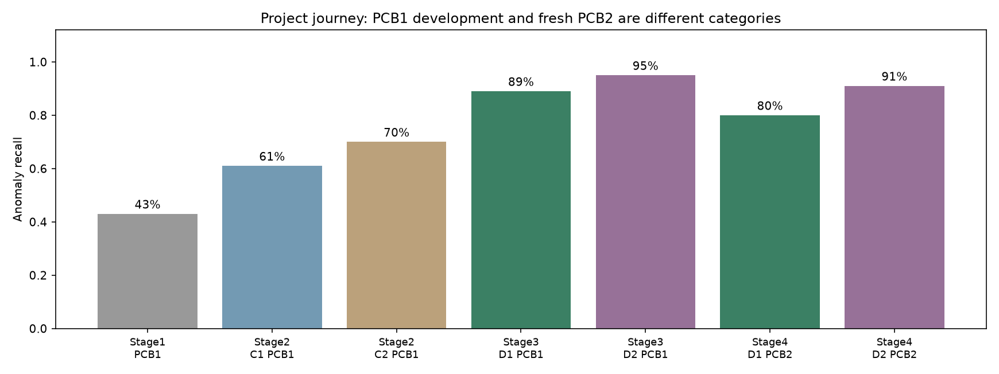

In [5]:
show_figure('score_distributions.png')
show_figure('runtime_review_burden.png')
show_table('runtime.csv')
show_table('runtime_phases.csv')
show_table('pcb1_vs_pcb2.csv')
show_figure('journey.png')

## Declared qualitative selection

Examples follow the frozen priority rule, ID tie breaks and deduplication rather
than replacing unfavorable outcomes. Cyan annotations retain the source region.
Map displays use each recipe's raw score divided by its frozen pixel threshold;
ratios and clipped colors are not defect probabilities. These sheets support
inspection, not tuning.

,image_id,reason,additional_reasons
0,a37c1228e9ff3279e16377fc,TP smallest positive primary margin,[]
1,7c459783721c82f677ac35c7,TP smallest positive primary margin,[]
2,696b15fa7935c77bc6332efd,FN closest below primary threshold,[]
3,8a393ef07e4999ab89669d93,FN closest below primary threshold,[]
4,2662b4037283d35b28570faf,FP largest primary score,[]
5,4f15590f560ec8dab6dc09f2,FP largest primary score,[]
6,989748a316d5781c15aa24a6,smallest common-mask area,[]
7,bfebbd19caf4dad38fd66eab,smallest common-mask area,[]
8,846cfdd3fbe431251239629c,largest common-mask area,[]
9,76964f3ab9f7c03b08de6900,largest common-mask area,[]


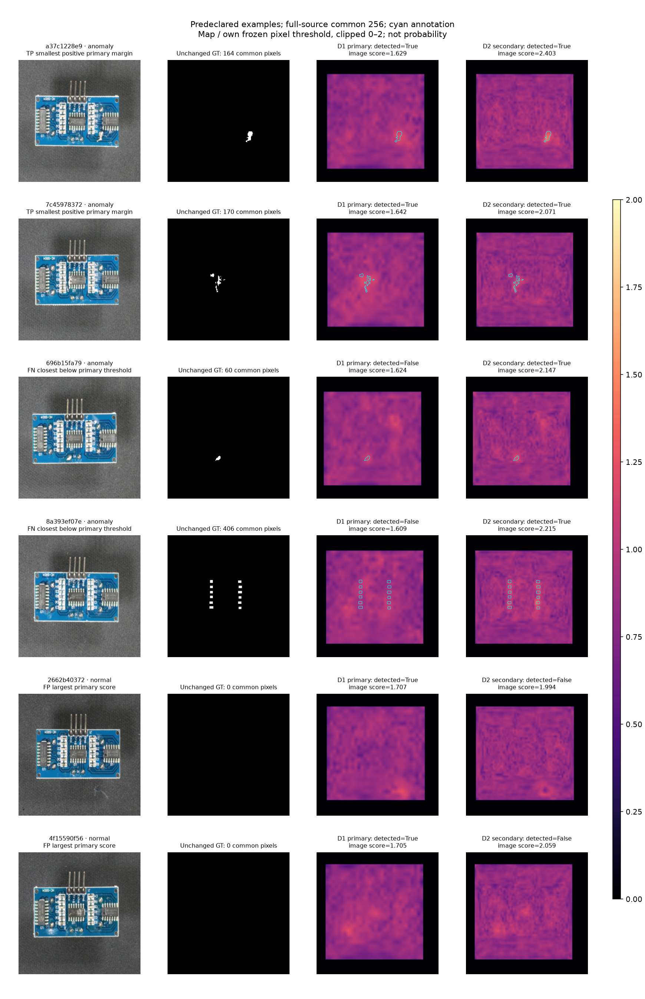

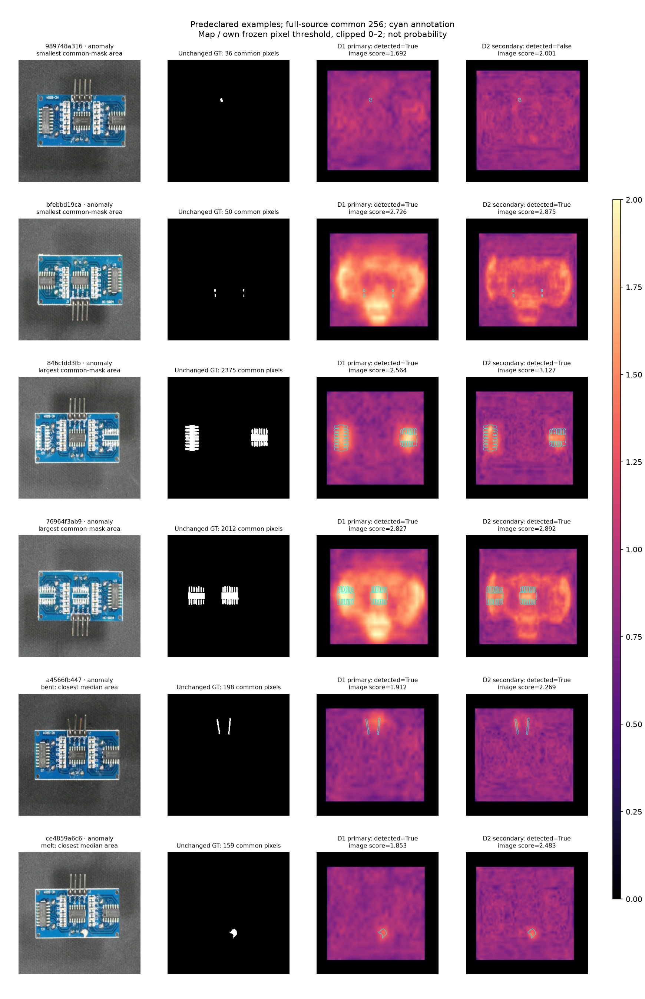

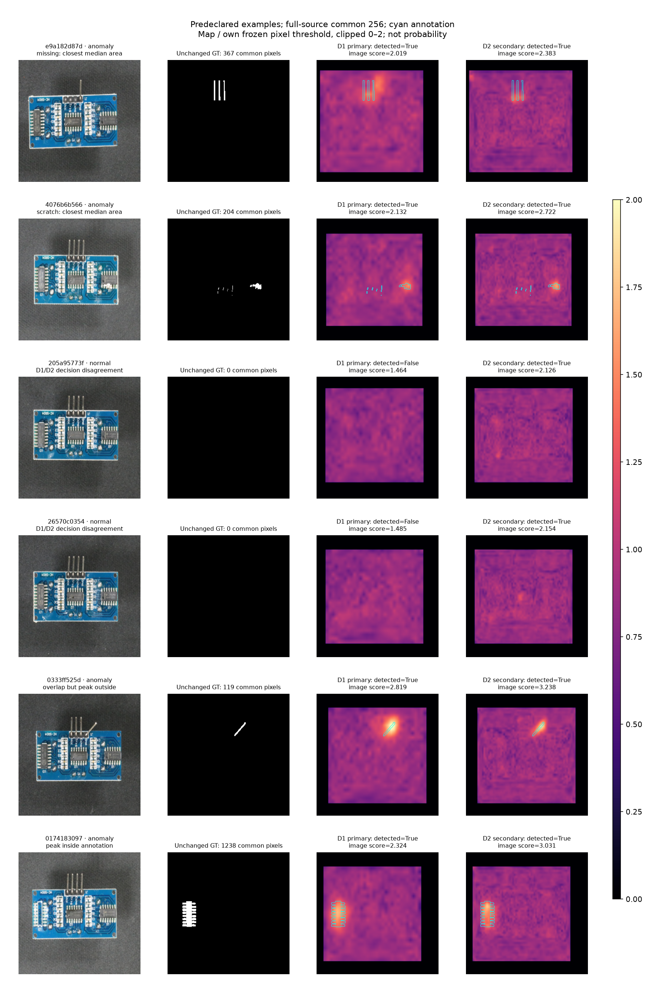

,image_id,recipe,label,score,detected,pixel_ap,peak_inside,overlap
0,a37c1228e9ff3279e16377fc,D1 primary,anomaly,1.6288,True,0.6583,True,True
1,a37c1228e9ff3279e16377fc,D2 secondary,anomaly,2.4026,True,0.7724,True,True
2,7c459783721c82f677ac35c7,D1 primary,anomaly,1.6425,True,0.1158,False,True
3,7c459783721c82f677ac35c7,D2 secondary,anomaly,2.0706,True,0.3589,True,True
4,696b15fa7935c77bc6332efd,D1 primary,anomaly,1.6241,False,0.1138,False,True
5,696b15fa7935c77bc6332efd,D2 secondary,anomaly,2.1467,True,0.8424,True,True
6,8a393ef07e4999ab89669d93,D1 primary,anomaly,1.6092,False,0.0369,False,True
7,8a393ef07e4999ab89669d93,D2 secondary,anomaly,2.2154,True,0.3163,True,True
8,2662b4037283d35b28570faf,D1 primary,normal,1.7066,True,NaN,False,False
9,2662b4037283d35b28570faf,D2 secondary,normal,1.9937,False,NaN,False,False


In [6]:
qualitative = load_json(folder / 'qualitative_metadata.json')
assert qualitative['new_inference'] is False
assert qualitative['selection_sha256'] == sha(folder / 'qualitative_selection.csv')
show_table('qualitative_selection.csv')
for page in qualitative['pages']:
    show_figure(page)
show_table('qualitative_metrics.csv')

## Interpretation and limits

Read the primary result first and retain the secondary result without substituting
it after seeing outcomes. This evaluates one frozen category-adaptation procedure
on PCB2; it does not establish factory readiness, cross-category statistical
equivalence, or a causal benefit of coreset selection. Pose ambiguity, resolution,
reference budget and the particular source dataset remain limitations.

Application/UI, LLM integration and Stage5 work are deferred. The report provenance
below identifies the saved evidence behind this companion; execution verifies
small report and receipt hashes without touching raw inputs or model arrays.

In [7]:
display(pd.DataFrame({'saved_source': list(metadata['sources']),
                      'sha256': list(metadata['sources'].values())}))
print('Notebook execution completed from saved artifacts only.')

,saved_source,sha256
0,artifacts/pcb1_memory_selection_comparison/com...,50349a06f4355a42066418de9a90e3cfd8f2897e9ac4df...
1,artifacts/runs/coreset_256_v1/metrics.json,05a708af77db3e51a577d8132be85d03b1b52dedf8e9e1...
2,artifacts/runs/coreset_512_v1/metrics.json,02cb4cd4c61a9ab6741a0246261313d8e2e55c02803462...
3,artifacts/stage4/freeze_receipt.json,a574ab907b9c871dbd55778fa5374b61c4c0d1bd988272...
4,artifacts/stage4/pcb2_d1_primary/calibration.json,2014cd7fe7cef22d644f7fbfaf849260e4d5c92304c8a3...
5,artifacts/stage4/pcb2_d1_primary/calibration_p...,1f8c71acdf322cbb663cef48bfaa7e33e579dd0bdfb23d...
6,artifacts/stage4/pcb2_d1_primary/complete.json,7302c119c1771520d3b190a2ee891c3a02ae4a112e973b...
7,artifacts/stage4/pcb2_d1_primary/independent_r...,7dcddd7243e5269c6a26501583867227eb5c9dbb4b3cbf...
8,artifacts/stage4/pcb2_d1_primary/metrics.json,1a6d537bb1ffab9b656f714e90ded3875a15dabb156d58...
9,artifacts/stage4/pcb2_d1_primary/normal_runtim...,91c781e81272bbc9ad95f0cf33bac02e86052726ce3182...


Notebook execution completed from saved artifacts only.
